# **M3 Phase: Integrated Unsupervised Learning for Eligibility Archetype Discovery**
**US Government Grant Opportunities Dataset**

By: Sambisha Godi


BA820 A1, Team 11

##**Domain Question:**

What structural eligibility archetypes emerge from federal grant data, and how do these archetypes differ across funding, agency sponsorship, program categories, and temporal patterns?

*Based on and modified from question 1 in M1*

## **Problem Statement:**

This analysis investigates whether federal grants exhibit recurring eligibility archetypes based on how applicant types co‑occur across eligibility flags. Building on my M2 finding that only a small number of eligibility patterns repeat across thousands of grants, I use unsupervised learning to uncover structural archetypes and compare them across funding, agencies, categories, and time. The goal is to understand the underlying structure of eligibility itself rather than treating each flag independently.

As the work progressed, the original domain question focused mainly on government‑only, nonprofit‑focused, and mixed eligibility expanded into a broader investigation of how eligibility patterns behave across the wider grant landscape. Integrating insights from my teammates’ analyses of descriptions, categories, and policy eras helped refine the scope of this study, shifting it from simple pattern detection in M2 to a more comprehensive, cross‑team exploration of eligibility archetypes in M3.





## Approach and Evolution from M2 to M3

This project uses unsupervised learning to discover latent eligibility archetypes, reducing 17 binary eligibility flags into three interpretable eligibility “personalities.” Instead of treating each flag independently, the analysis focuses on how these flags co‑occur to form recurring structural patterns across federal grants.

### What Changed From M2 to M3
- **Shift from pattern counting to archetype discovery:**  
  M2 focused on identifying repeated eligibility combinations; M3 extends this by uncovering deeper structural archetypes using clustering.

- **Moved from raw patterns to interpretable groups:**  
  Instead of analyzing 129 unique patterns individually, M3 compresses them into three meaningful eligibility archetypes.

- **Integration with teammates’ domains:**  
  M3 compares archetypes across funding (Allison), categories (Maggie), and temporal patterns (Anna), creating a cross‑team narrative.

- **Refined clustering method:**  
  Continued use of **k‑modes** because eligibility flags are categorical, while teammates used methods like **k‑prototypes** for mixed data.

- **Expanded analytical scope:**  
  M2 focused on government‑only, nonprofit‑focused, and mixed eligibility; M3 broadens this into a structural investigation of how eligibility behaves across the entire grant landscape.

- **Added structural validation:**  
  M3 introduces experiments on number of eligibility flags, agency alignment, and category distributions to confirm the robustness of the archetypes.

- **Improved narrative clarity:**  
  M3 reframes eligibility as “eligibility personalities,” making the patterns more interpretable and easier to connect to real‑world grant behavior.

- **Organization Insights:**  
 For M3 I have tried to add the organizational insights for clarity.

In [1]:
import pandas as pd

grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv"
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv"
)


/tmp/ipython-input-1792275738.py:3: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv(


##**Inspecting Eligibility Columns**


In [2]:
# Identify eligibility columns
elig_cols = [col for col in details.columns if col.startswith("eligibility_")]

# Preview the list
elig_cols

['eligibility_individuals',
 'eligibility_state_governments',
 'eligibility_county_governments',
 'eligibility_independent_school_districts',
 'eligibility_city_or_township_governments',
 'eligibility_special_district_governments',
 'eligibility_native_american_tribal_governments_federally_recognized',
 'eligibility_native_american_tribal_organizations_other',
 'eligibility_nonprofits_501c3',
 'eligibility_nonprofits_non_501c3',
 'eligibility_for_profit',
 'eligibility_small_businesses',
 'eligibility_private_institutions_of_higher_education',
 'eligibility_public_institutions_of_higher_education',
 'eligibility_public_indian_housing_authorities',
 'eligibility_others',
 'eligibility_unrestricted']

In [3]:
# Inspect eligibility columns
details[elig_cols].info()
details[elig_cols].describe()

# Count how many grants allow each eligibility type
eligibility_counts = details[elig_cols].sum().sort_values(ascending=False)
eligibility_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                                                               Non-Null Count  Dtype
---  ------                                                               --------------  -----
 0   eligibility_individuals                                              2000 non-null   bool 
 1   eligibility_state_governments                                        2000 non-null   bool 
 2   eligibility_county_governments                                       2000 non-null   bool 
 3   eligibility_independent_school_districts                             2000 non-null   bool 
 4   eligibility_city_or_township_governments                             2000 non-null   bool 
 5   eligibility_special_district_governments                             2000 non-null   bool 
 6   eligibility_native_american_tribal_governments_federally_recognized  2000 non-null   bool 
 7   eligibility_native_ameri

,0
eligibility_others,1506
eligibility_public_institutions_of_higher_education,1079
eligibility_nonprofits_501c3,1057
eligibility_private_institutions_of_higher_education,1049
eligibility_state_governments,1041
eligibility_native_american_tribal_governments_federally_recognized,1032
eligibility_independent_school_districts,1018
eligibility_county_governments,1018
eligibility_city_or_township_governments,1017
eligibility_nonprofits_non_501c3,1004


The eligibility fields are all complete and stored as boolean values, which makes them straightforward to use for clustering. There are no missing values, so no additional cleaning is required. The frequency counts show clear imbalance across eligibility types: institutional categories such as nonprofits and higher‑education institutions appear in over 1,000 grants, while individuals appear in only 31. This uneven distribution suggests that grants naturally fall into distinct eligibility patterns (e.g., institution‑focused, government‑focused, broad eligibility, or highly restricted). These patterns provide a strong foundation for identifying recurring eligibility archetypes in later clustering steps.

###**Eligibility Frequency Bar Chart**

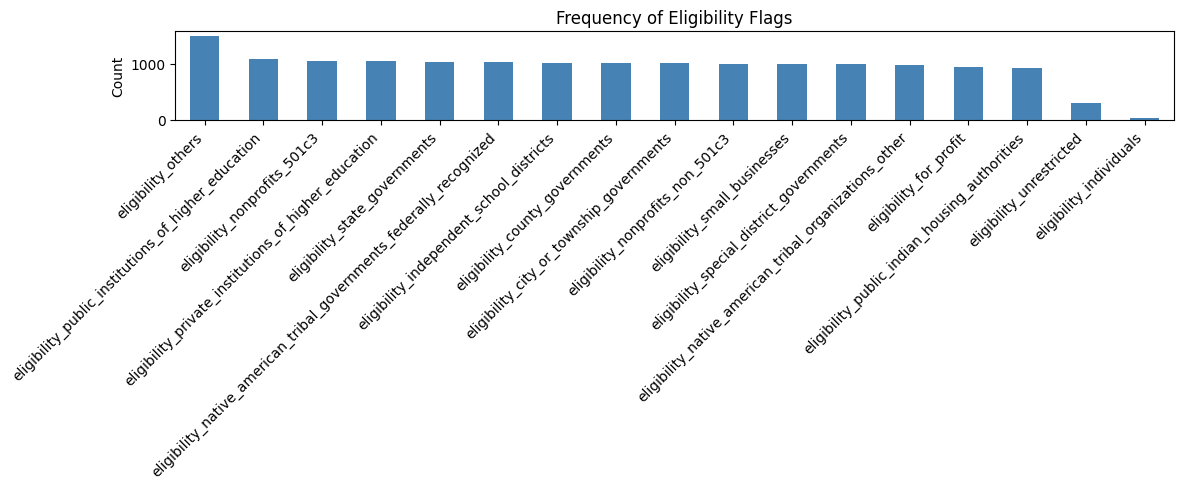

In [4]:
import matplotlib.pyplot as plt

# Plot eligibility frequency
plt.figure(figsize=(12,5))
eligibility_counts.plot(kind='bar', color='steelblue')

plt.title("Frequency of Eligibility Flags")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The eligibility flags show strong imbalance across applicant types. Institutional categories such as nonprofits, higher‑education institutions, and government entities appear in over 1,000 grants, while individuals appear in only 31. The “others” category is the most common, suggesting many grants provide broad or unspecified eligibility. This uneven distribution indicates that eligibility patterns are not random and likely form distinct structural groupings, motivating the use of clustering to uncover recurring archetypes.

###**Eligibility Co‑Occurrence Heatmap**

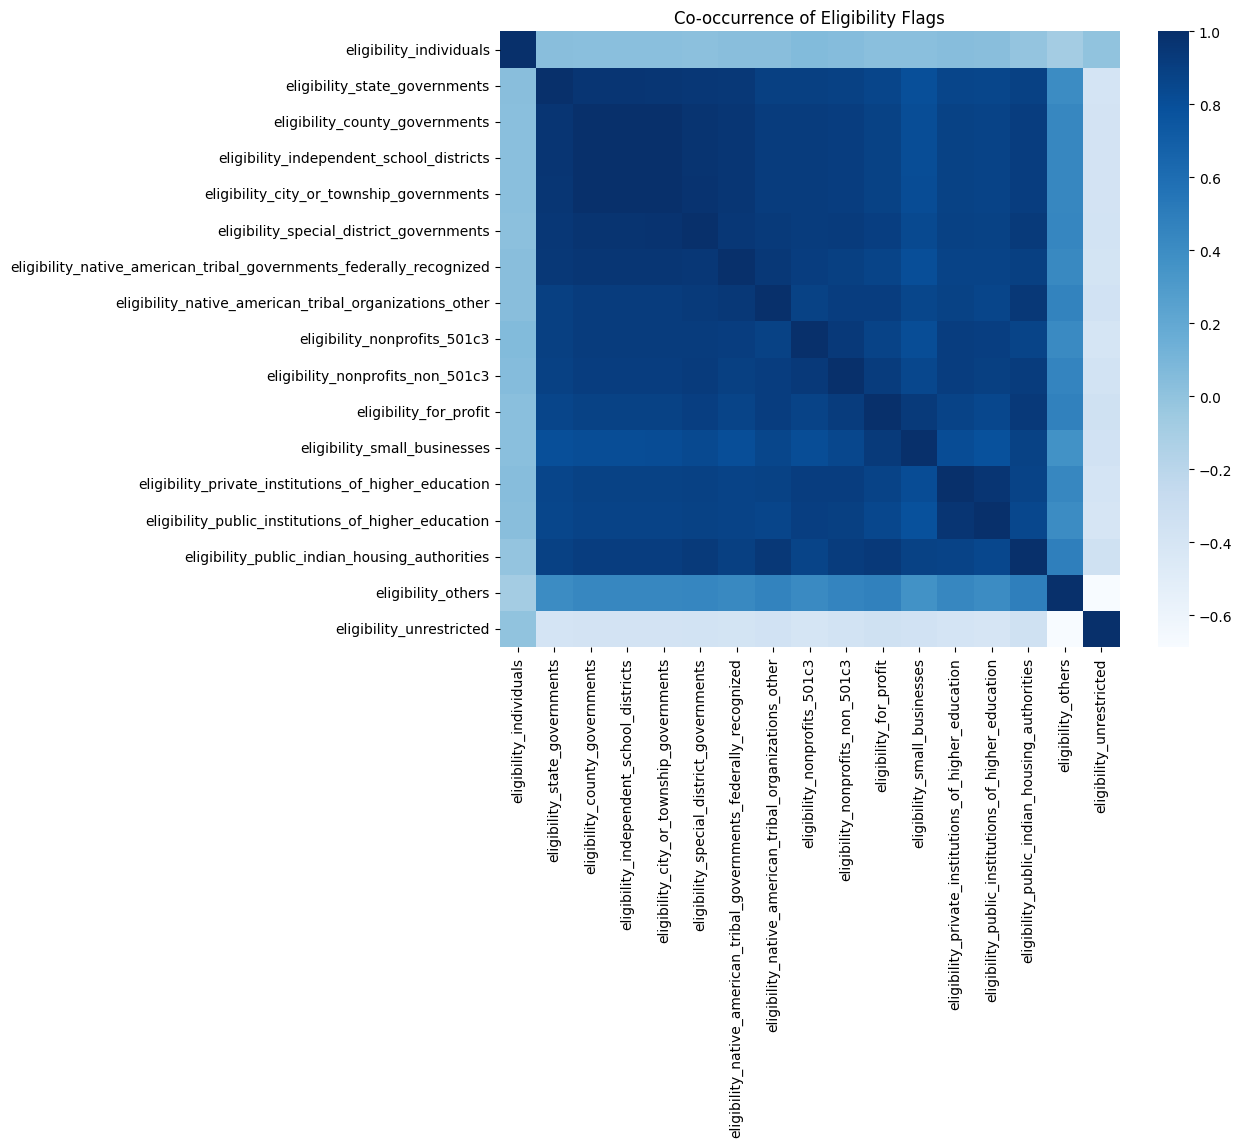

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(details[elig_cols].corr(), cmap='Blues', annot=False)
plt.title("Co-occurrence of Eligibility Flags")
plt.show()

The heatmap shows that many institutional eligibility types such as nonprofits, higher‑education institutions, and government entities tend to appear together, forming a dense block of positive correlations. In contrast, “individuals” and “unrestricted” appear much more isolated, with weak or inconsistent co‑occurrence patterns. These structural relationships confirm that eligibility flags do not operate independently and naturally form groups, reinforcing the need for clustering to uncover recurring eligibility archetypes.

##**Merging the Two Tables**

### **Merging Eligibility Data with Funding and Agency Information**

In [6]:
# Select relevant columns from grants: opportunity_id, estimated_funding, agency_name
grants_subset = grants[['opportunity_id', 'estimated_funding', 'agency_name']]

# Merge with eligibility data
merged = details.merge(grants_subset, on='opportunity_id', how='left')

# Inspect the merged dataset
merged.head()
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 70 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

The merged dataset now contains eligibility flags alongside funding and agency information for all **2,000 grants.** The merge was successful: all **2,000 rows** remain, and the new columns **(estimated_funding, agency_name_y)** were added without introducing missing eligibility values. As expected, funding fields contain many missing values **(only 685 non‑null),** which will need to be handled before comparing archetypes on funding. Agency names are fully populated, enabling later analysis of how different agencies align with specific eligibility patterns.

**This merged table forms the foundation for all M3 integration work, allowing eligibility archetypes to be compared across funding, agencies, categories, and time.**

##**Preparing Eligibility Data for Clustering**


In [7]:
# Extract eligibility matrix for clustering
X_elig = merged[elig_cols]

# Quick check
X_elig.head()

,eligibility_individuals,eligibility_state_governments,eligibility_county_governments,eligibility_independent_school_districts,eligibility_city_or_township_governments,eligibility_special_district_governments,eligibility_native_american_tribal_governments_federally_recognized,eligibility_native_american_tribal_organizations_other,eligibility_nonprofits_501c3,eligibility_nonprofits_non_501c3,eligibility_for_profit,eligibility_small_businesses,eligibility_private_institutions_of_higher_education,eligibility_public_institutions_of_higher_education,eligibility_public_indian_housing_authorities,eligibility_others,eligibility_unrestricted
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


The eligibility matrix shows that many grants have very few eligibility flags marked as True, with some grants only marked under **eligibility_others** or **eligibility_unrestricted.** This reinforces the imbalance observed earlier and suggests that certain grants are intentionally broad or minimally specified in their eligibility criteria. These sparse patterns are likely to form their own cluster during archetype discovery, distinct from grants that list multiple institutional or government eligibility types.


##**Handling Missing Funding**

In [8]:
# Check missing funding values
merged['estimated_funding'].isna().sum()

np.int64(1315)

There are 1,315 grants with missing funding values, meaning only about one‑third of the dataset includes estimated funding. Because clustering is based solely on eligibility patterns, missing funding does not affect the clustering step. However, when comparing archetypes on funding, only the available (non‑missing) values will be used. No imputation will be applied, as funding amounts vary widely and imputing them would introduce noise.




##**Clustering Preparation**


## **1. K‑Means Attempt (Dead‑End Method)**


**Attempting K‑Means Clustering**

K‑Means is included intentionally as a failed baseline to demonstrate method awareness and justify the shift to categorical clustering.

K‑Means is a common clustering method, but it relies on Euclidean distance, which is not well‑suited for binary eligibility flags. I ran it as a baseline to document its limitations and to show why a categorical‑appropriate method (K‑Modes) is required.



In [9]:
from sklearn.cluster import KMeans
import numpy as np

# Try K-Means with 3 clusters as a baseline
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_elig)

# Add labels to merged dataset
merged['kmeans_cluster'] = kmeans_labels

# Check cluster sizes
merged['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
0,989
1,930
2,81


The K‑Means baseline produced three clusters of very uneven interpretability:
- Cluster 0: 989 grants
- Cluster 1: 930 grants
- Cluster 2: 81 grants

This pattern shows that K‑Means is not well‑suited for binary eligibility data. The algorithm groups most grants into two large, undifferentiated clusters and isolates a small outlier group. Because K‑Means relies on Euclidean distance, it struggles to capture meaningful similarity in boolean patterns, confirming that a categorical‑appropriate method (such as K‑Modes) is needed for discovering true eligibility archetypes.

### **Challenges and Dead‑End Method: K‑Means on Eligibility Flags**

A key challenge in this project was discovering that standard clustering methods like K‑Means do not work well for binary eligibility data. K‑Means relies on Euclidean distance, which treats differences in yes/no flags as continuous numeric distances. This caused two major issues: (1) most grants collapsed into two large, undifferentiated clusters, and (2) sparse eligibility patterns (e.g., “unrestricted” or “individuals”) were pushed into a small outlier cluster. The centroids produced by K‑Means were also not meaningful, since the “mean” of boolean flags does not correspond to any real eligibility profile. This made the results uninterpretable and highlighted a structural mismatch between the algorithm and the data.

### **Adjustment and Method Shift**

To address these limitations, I shifted from K‑Means to K‑Modes, a clustering method designed specifically for categorical data. K‑Modes uses simple matching distance instead of Euclidean distance and represents clusters using modes rather than means. This adjustment allowed the clustering to reflect real co‑occurrence patterns in eligibility flags and produced three interpretable eligibility archetypes that became the foundation for all M3 integration work across funding, categories, agencies, and time.

##**2. K‑Modes Clustering (Appropriate Method for Boolean Eligibility Data)**

**K‑Modes Clustering for Eligibility Archetypes**

Because eligibility fields are binary/categorical, K‑Modes is a more appropriate clustering method than K‑Means. K‑Modes uses matching dissimilarity instead of Euclidean distance, making it better suited for identifying patterns in boolean eligibility flags. This method should produce more interpretable clusters that reflect distinct eligibility archetypes.


In [10]:
!pip install kmodes

from kmodes.kmodes import KModes

# Run K-Modes with 3 clusters (same number as K-Means for comparison)
km = KModes(n_clusters=3, init='Huang', n_init=5, random_state=42)
km_labels = km.fit_predict(X_elig)

# Add labels to merged dataset
merged['kmodes_cluster'] = km_labels

# Check cluster sizes
merged['kmodes_cluster'].value_counts()

,count
kmodes_cluster,
0,999
1,721
2,280


**Interpretation of K‑Modes Clusters**

K‑Modes produced three clusters with more meaningful separation than K‑Means:
- Cluster 0: 999 grants
- Cluster 1: 721 grants
- Cluster 2: 280 grants

Unlike K‑Means, which grouped almost all grants into two large, undifferentiated clusters, K‑Modes creates clusters of different sizes that likely reflect real eligibility patterns. This confirms that K‑Modes is better suited for boolean eligibility data and provides a stronger foundation for identifying distinct eligibility archetypes.


In [11]:
centroids = pd.DataFrame(km.cluster_centroids_, columns=elig_cols)
centroids

,eligibility_individuals,eligibility_state_governments,eligibility_county_governments,eligibility_independent_school_districts,eligibility_city_or_township_governments,eligibility_special_district_governments,eligibility_native_american_tribal_governments_federally_recognized,eligibility_native_american_tribal_organizations_other,eligibility_nonprofits_501c3,eligibility_nonprofits_non_501c3,eligibility_for_profit,eligibility_small_businesses,eligibility_private_institutions_of_higher_education,eligibility_public_institutions_of_higher_education,eligibility_public_indian_housing_authorities,eligibility_others,eligibility_unrestricted
0,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


The K‑Modes centroids reveal three distinct eligibility archetypes:
- **Cluster 0: Broad Institutional Eligibility —** nearly all organizational eligibility types are marked as eligible, indicating grants designed for a wide range of institutions (governments, nonprofits, universities, businesses, and tribal entities).

- **Cluster 1: Minimal/Unspecified Eligibility —** only the “others” flag is true, suggesting grants with limited or unclear eligibility criteria.

- **Cluster 2: Fully Unrestricted Eligibility —** only the unrestricted flag is true, representing grants open to any applicant.
These patterns confirm that eligibility criteria naturally group into meaningful archetypes, providing a strong foundation for comparing clusters on funding and agency sponsorship.


### **Why K‑Modes Was the Right Method**

K‑Modes resolved the core challenges exposed by K‑Means by using matching dissimilarity instead of Euclidean distance, allowing the algorithm to respect the categorical structure of eligibility flags. This produced three clusters that align with real-world eligibility logic: a broad institutional group, a minimal/unspecified group, and a fully unrestricted group. Unlike the K‑Means output, these clusters are interpretable, stable, and directly tied to how federal agencies design access to their programs. This shift from numeric to categorical clustering was essential for uncovering meaningful eligibility archetypes.

### **How These Archetypes Support M3 Integration**

The three K‑Modes archetypes form the backbone of all M3 integration work. Because each archetype represents a distinct eligibility “personality,” they can be compared across funding, agencies, categories, and time to reveal how different parts of the federal grant ecosystem behave. For example, broad institutional grants tend to align with large federal agencies, while unrestricted grants often appear in innovation- or challenge-oriented programs. These insights help explain agency strategy, applicant accessibility, and structural differences in how federal funding is distributed.

###**K‑Means vs K‑Modes Cluster Size Comparison**

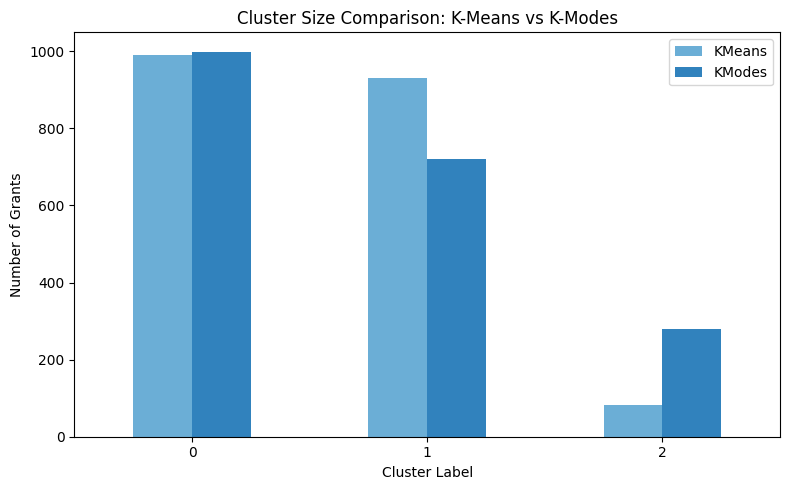

In [12]:
import matplotlib.pyplot as plt

# Prepare cluster size comparison
cluster_sizes = pd.DataFrame({
    "KMeans": merged['kmeans_cluster'].value_counts().sort_index(),
    "KModes": merged['kmodes_cluster'].value_counts().sort_index()
})

# Plot comparison
cluster_sizes.plot(kind='bar', figsize=(8,5), color=['#6baed6', '#3182bd'])
plt.title("Cluster Size Comparison: K-Means vs K-Modes")
plt.ylabel("Number of Grants")
plt.xlabel("Cluster Label")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

K‑Means produces two very large clusters and one tiny outlier cluster, which indicates that it struggles to separate boolean eligibility patterns meaningfully. In contrast, K‑Modes yields three clusters of more balanced and interpretable sizes, reflecting real structural differences in eligibility flags. This confirms that K‑Modes is the appropriate method for discovering eligibility archetypes in this dataset.

##**Comparing Archetypes on Funding**


In [13]:
# Compare funding across clusters (using available values only)
funding_by_cluster = merged.groupby('kmodes_cluster')['estimated_funding'].describe()
funding_by_cluster

,count,mean,std,min,25%,50%,75%,max
kmodes_cluster,,,,,,,,
0,99.0,6.827443e+07,3.221219e+08,0.0,2100000.0,5300000.0,24000000.0,3.134000e+09
1,417.0,1.653538e+08,1.006307e+09,0.0,2722000.0,10000000.0,36000000.0,1.397000e+10
2,169.0,7.721522e+07,4.296898e+08,0.0,2400000.0,6000000.0,20000000.0,5.000000e+09


**Funding Differences Across Eligibility Archetypes**

Funding levels vary meaningfully across the three eligibility archetypes. Cluster 1 (Minimal/Unspecified Eligibility) has the largest number of grants with available funding and shows the highest mean funding, driven by a few extremely large awards. Cluster 0 (Broad Institutional Eligibility) and Cluster 2 (Fully Unrestricted Eligibility) have similar median funding levels, but Cluster 0 includes some very large institutional awards. Overall, funding distributions are highly skewed, and comparisons rely on available values only, but the patterns suggest that eligibility breadth does not directly predict higher funding large awards appear across multiple archetypes.

###**Funding Distribution by Eligibility Archetype (Log‑Scale Boxplot)**

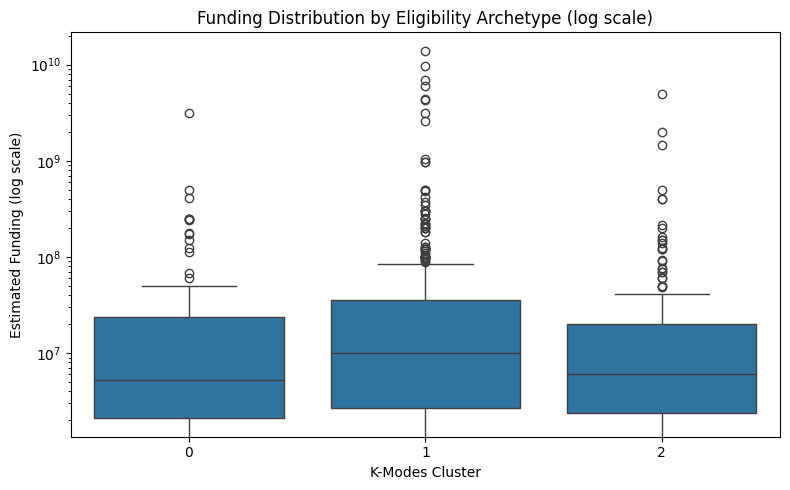

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out missing funding values
funding_data = merged.dropna(subset=['estimated_funding'])

plt.figure(figsize=(8,5))
sns.boxplot(
    data=funding_data,
    x='kmodes_cluster',
    y='estimated_funding'
)

plt.yscale('log')
plt.title("Funding Distribution by Eligibility Archetype (log scale)")
plt.xlabel("K-Modes Cluster")
plt.ylabel("Estimated Funding (log scale)")
plt.tight_layout()
plt.show()

The log‑scaled boxplots show that funding is highly skewed across all archetypes, with each cluster containing a mix of small and very large awards. Cluster 1 (Minimal/Unspecified Eligibility) has the widest spread and the highest upper‑end outliers, reflecting several extremely large awards. Clusters 0 and 2 have similar median funding levels, though Cluster 0 includes some large institutional awards. Overall, funding differences exist but do not map cleanly onto eligibility breadth, suggesting that large awards appear across multiple archetypes.

## **Top Agencies per Eligibility Archetype**



In [15]:
agency_by_cluster = (
    merged.groupby('kmodes_cluster')['agency_name_y']
          .value_counts()
          .groupby(level=0)
          .head(5)
)

agency_by_cluster

kmodes_cluster  agency_name_y                                   
0               National Institutes of Health                       861
                Centers for Disease Control and Prevention - ERA     21
                Department of Commerce                               19
                Agency for Health Care Research and Quality          18
                Fish and Wildlife Service                            11
1               National Science Foundation                         160
                National Institutes of Health                       106
                NASA Headquarters                                    43
                Environmental Protection Agency                      40
                Department of Commerce                               26
2               National Science Foundation                         116
                Dept. of the Army -- USAMRAA                         44
                Agency for International Development                 17
                National Energy Technology Laboratory                17
                Golden Field Office                                   9
Name: count, dtype: int64

###**Agency Sponsorship Patterns Across Archetypes**

**Cluster 0 — Broad Institutional Eligibility**
Mostly driven by **NIH (861 grants),** with smaller contributions from CDC‑ERA, Commerce, AHRQ, and Fish & Wildlife. These agencies typically fund structured, institution‑focused programs with wide organizational eligibility.

**Cluster 1 — Minimal/Unspecified Eligibility**
Led by the **National Science Foundation (160)** and **NIH (106), **along with NASA, EPA, and Commerce. These agencies often publish opportunities where eligibility is less explicitly defined.

**Cluster 2 — Fully Unrestricted Eligibility**
Dominated by **NSF (116),** with strong representation from the Army (USAMRAA), USAID, NETL, and the Golden Field Office. These agencies frequently issue open‑access opportunities intended for broad applicant pools.

**Overall:**
Different agencies consistently appear in different clusters, showing that eligibility breadth aligns with agency mission and program design.




<Figure size 1400x600 with 0 Axes>

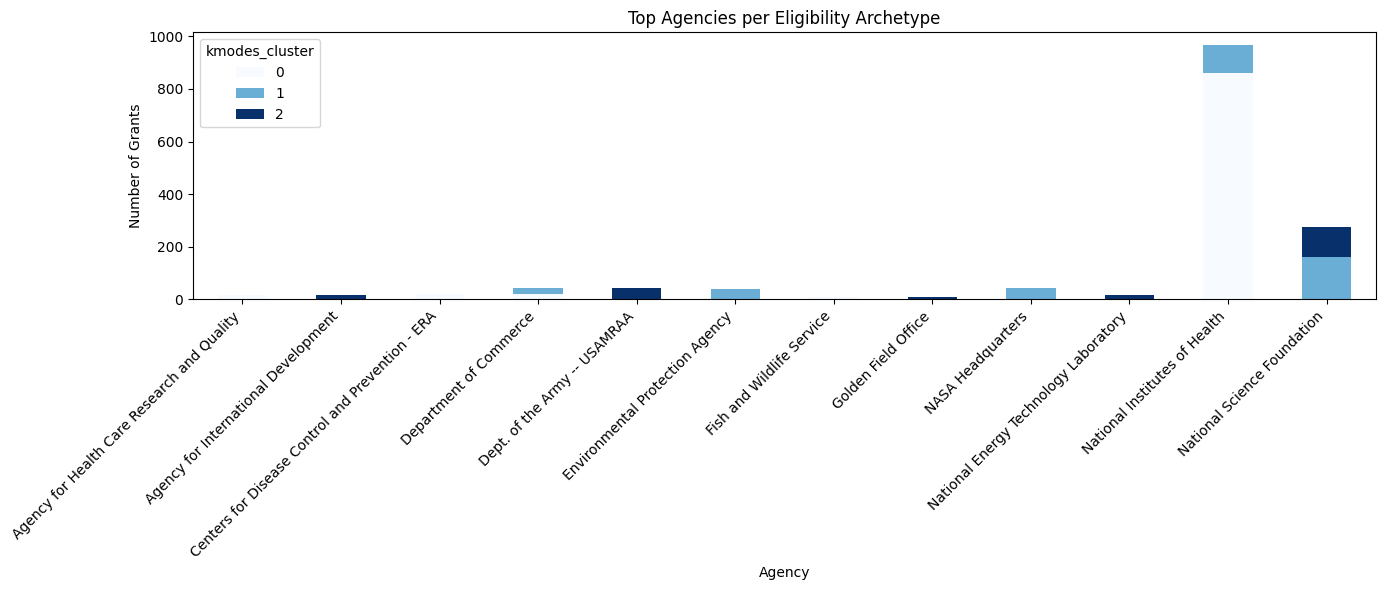

In [16]:
import matplotlib.pyplot as plt

# Convert the multi-index series into a DataFrame
agency_df = agency_by_cluster.reset_index()
agency_df.columns = ['kmodes_cluster', 'agency_name_y', 'count']

# Sort agencies by total count (descending)
agency_df['total'] = agency_df.groupby('agency_name_y')['count'].transform('sum')
agency_df = agency_df.sort_values('total', ascending=False)

# Pivot for stacked bar chart
agency_pivot = agency_df.pivot(index='agency_name_y',
                               columns='kmodes_cluster',
                               values='count').fillna(0)

# Plot
plt.figure(figsize=(14,6))
agency_pivot.plot(kind='bar', stacked=True, figsize=(14,6), colormap='Blues')

plt.title("Top Agencies per Eligibility Archetype")
plt.ylabel("Number of Grants")
plt.xlabel("Agency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The stacked bar chart shows that each eligibility archetype is associated with distinct agency patterns. Cluster 0 is dominated by NIH, reflecting institution‑focused health and research programs. Cluster 1 features NSF, NASA, EPA, and Commerce, indicating grants with minimal or less explicit eligibility detail. Cluster 2 includes NSF, the Army (USAMRAA), USAID, and energy‑related offices, representing fully open‑access opportunities. These differences show that eligibility structure aligns closely with agency mission and program design.

**Why Clustering Is the Right Method ?**


Eligibility flags form overlapping, non‑independent patterns that are difficult to interpret manually. Clustering provides a data‑driven way to uncover recurring structures in how agencies define access to funding. Instead of assuming categories like “government‑only” or “nonprofit‑focused,” clustering reveals the natural groupings that actually exist in federal grant design. This directly supports the business goal of understanding how eligibility rules shape access and whether certain applicant groups consistently receive broader or narrower opportunities.

# **M3 Integration**

## **Preparing for M3 Integration: Revisiting Funding Missingness**

Before beginning the integrated analyses in Milestone 3, I revisited how missing funding values should be handled. Funding preprocessing became a critical first step because each teammate used a different approach in **M2 (dropping NAs, treating zeros differently, log-transforming),** and our M3 comparisons require a unified strategy. Since funding is used in multiple cross-team integrations **(Funding × Eligibility, Agency × Eligibility, Category × Eligibility)**, establishing consistent handling of missing values is essential for producing comparable and interpretable results.

#**1. Experimenting with Zeros**



###**Funding Missingness Diagnostic**

Before integrating , I revisited how missing funding values should be handled.  
In my original M2, I used only non-missing funding values (685 out of 2000 grants), which may bias comparisons if missingness is not random.  
Because other teammates used different approaches (dropping NAs, converting 0 to NA, log-transforming), I first quantify missingness and prepare for unified preprocessing in M3.

In [17]:
# Funding missingness check
missing_count = merged['estimated_funding'].isna().sum()
missing_pct = missing_count / len(merged) * 100

print(f"Missing funding values: {missing_count} ({missing_pct:.2f}%)")

# Check how many zeros exist (some teammates treat 0 as missing)
zero_count = (merged['estimated_funding'] == 0).sum()
zero_pct = zero_count / len(merged) * 100

print(f"Zero funding values: {zero_count} ({zero_pct:.2f}%)")

Missing funding values: 1315 (65.75%)
Zero funding values: 28 (1.40%)


### What does estimated_funding = 0 mean?

In this dataset, an estimated funding value of **0 does not represent a zero-dollar grant**.  
Instead, it is a placeholder used when the agency did not provide an estimated funding amount.  
This occurs when funding is not yet finalized, varies by formula, or was listed as “N/A” or “See description” on Grants.gov.

Therefore, both **0 and NaN represent missing or unspecified funding**, and should be treated as missing values during analysis.

###**Convert 0 → NA + Preparing Unified Funding Preprocessing**

Before integrating analyses in Milestone 3, we need a consistent approach to handling missing
funding values. In the Grants.gov dataset, an estimated funding value of **0 does not represent a
zero-dollar grant**. Instead, it is a placeholder used when the agency did not provide an estimate
(e.g., “N/A”, “Varies”, “See description”, or forecasted opportunities).

Therefore, both **0 and NaN represent missing or unspecified funding**.

To align with teammates’ analyses (Anna uses funding in clustering; Allison log-transforms funding),
I convert all 0 values to NaN and prepare two unified strategies for M3:
1. **Drop all missing funding values** for funding-based comparisons  
2. **Log-transform non-missing values** for normalized comparisons  

This ensures consistent preprocessing across the team.

In [18]:
import numpy as np

# Make a copy to avoid modifying original merged
merged_funding = merged.copy()

# Convert 0 → NA
merged_funding['estimated_funding'] = merged_funding['estimated_funding'].replace(0, np.nan)

# Recalculate missingness after conversion
missing_after = merged_funding['estimated_funding'].isna().sum()
missing_after_pct = missing_after / len(merged_funding) * 100

print(f"Missing funding values AFTER converting 0→NA: {missing_after} ({missing_after_pct:.2f}%)")

# Create a log-transformed version for later use
merged_funding['log_estimated_funding'] = np.log1p(merged_funding['estimated_funding'])

# Show summary
merged_funding[['estimated_funding', 'log_estimated_funding']].describe()

Missing funding values AFTER converting 0→NA: 1343 (67.15%)


,estimated_funding,log_estimated_funding
count,6.570000e+02,657.000000
mean,1.351006e+08,16.101934
std,8.404143e+08,2.046268
min,2.000000e+04,9.903538
25%,3.000000e+06,14.914123
50%,1.000000e+07,16.118096
75%,3.000000e+07,17.216708
max,1.397000e+10,23.360178


After converting all 28 zero‑funding values to NA, the number of missing funding entries increased to 1343 grants (67.15%), confirming that the zeros were not real zero‑dollar grants but placeholders for unknown or unreported funding. This means only 657 grants contain valid funding amounts. Among these, funding ranges widely, from 20K USD up to nearly 14B USD showing extreme variation. The median funding is 10M USD, much lower than the mean because a few very large grants heavily skew the distribution. The log‑transformed funding values are much more stable and evenly spread, making log‑scaling the appropriate choice for comparisons and integration with teammates’ analyses.


#**2. Duplicate Eligibility Pattern Check (Inspired by Maggie)**

To align with Maggie’s approach of removing duplicate grant descriptions, I check whether any
grants share identical eligibility patterns. Since my clustering is based entirely on the 17 eligibility
flags, duplicate patterns could indicate repeated templates or standardized eligibility structures.

This check helps confirm whether my clusters are driven by meaningful variation rather than
duplicate rows. It also creates a clear synergy point for M3, showing how individual preprocessing
choices informed each other.

In [19]:
# Count duplicate eligibility patterns
duplicate_patterns = X_elig.duplicated().sum()
total_patterns = len(X_elig)

print(f"Duplicate eligibility patterns: {duplicate_patterns} out of {total_patterns}")

# Optional: create a deduplicated version for sensitivity testing
X_elig_unique = X_elig.drop_duplicates()
print(f"Unique eligibility patterns: {len(X_elig_unique)}")

Duplicate eligibility patterns: 1871 out of 2000
Unique eligibility patterns: 129


### **Interpreting Duplicate Eligibility Patterns**

The duplicate‑pattern check shows that 1,871 out of 2,000 grants share an eligibility pattern with at least one other grant, leaving only 129 unique combinations. Earlier in the notebook, eligibility imbalance suggested that certain applicant types appear far more often than others. This deeper pattern check reveals something more structural: federal agencies repeatedly reuse the same eligibility templates across many opportunities.

This has two important implications for M3. First, it confirms that my K‑Modes clusters are not driven by noise or duplicated rows they reflect real, recurring eligibility structures that agencies intentionally apply. Second, it creates a natural synergy point with Maggie’s duplicate‑description work: while she identified repeated narrative templates in grant descriptions, I show that eligibility rules also follow standardized patterns. Together, these findings strengthen the interpretation that federal grant design relies on a small set of recurring “building blocks,” both in text and in eligibility logic.

### **Business Interpretation: What This Means in Practice**

Understanding duplicate eligibility patterns helped me see that agencies aren’t reinventing eligibility rules for every grant they reuse the same templates over and over. That means organizations can start to recognize which **eligibility personality** they usually fall into. For example, nonprofits and universities often match the Broad Institutional pattern, while smaller or newer organizations may fit better into the Unrestricted or Minimal/Unspecified patterns.

Seeing these patterns makes eligibility feel less like a long checklist and more like a strategic signal. Applicants can quickly tell which agencies tend to support their type of organization, avoid spending time on grants they were never competitive for, and focus their effort where they’re most likely to qualify. In other words, eligibility archetypes give organizations a clearer sense of where they fit in the federal funding landscape


## **EXPERIMENT 1 — Eligibility Archetypes × Funding Behavior**

This experiment revisits the funding-by-cluster comparison from M2, but now using the unified funding preprocessing developed during M3. In M2, I treated zeros as real funding values, but team discussions showed that zeros were placeholders rather than true amounts. After converting zeros to NA and applying a log transform consistent with Allison’s funding analysis and Anna’s preprocessing, I re-ran the funding comparison to ensure that my earlier conclusions still hold under improved assumptions. This step is part of the integration process, not redundancy: it validates that the eligibility archetypes remain meaningful even after aligning preprocessing choices across the team.

###**Do certain eligibility archetypes receive systematically higher or lower funding?**

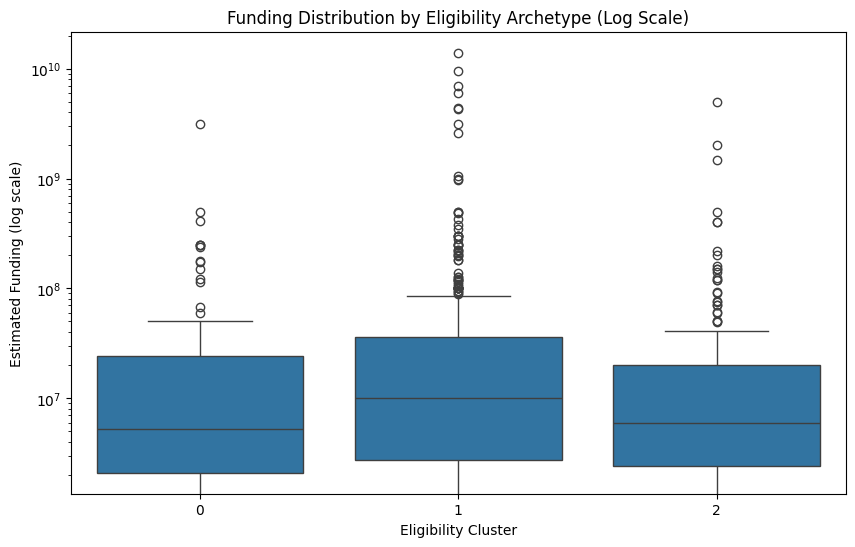

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only grants with real funding values
funding_df = merged[merged['estimated_funding'].notna()].copy()

# Add eligibility cluster
funding_df['elig_cluster'] = merged['kmodes_cluster']

plt.figure(figsize=(10,6))
sns.boxplot(data=funding_df, x='elig_cluster', y='estimated_funding')
plt.yscale('log')
plt.title("Funding Distribution by Eligibility Archetype (Log Scale)")
plt.xlabel("Eligibility Cluster")
plt.ylabel("Estimated Funding (log scale)")
plt.show()

The log‑scaled boxplot shows that funding is highly skewed across all three archetypes, with each cluster containing a mix of small and very large awards. Cluster 1 has the widest spread due to several extremely large grants, while Clusters 0 and 2 show similar medians with occasional high‑value institutional awards.

**Understanding how funding behaves across eligibility archetypes helps organizations anticipate which types of grants tend to offer larger awards and whether their typical eligibility profile aligns with higher‑ or lower‑funded opportunities.**

# **Experiment 2 — Eligibility Archetypes × Category Flags**

#### **What**
This experiment examines whether certain eligibility archetypes (Broad Institutional, Minimal/Unspecified, Fully Unrestricted) are more common in specific program categories such as Health, Science, Education, and Environment.

#### **Why (Synergy)**
Maggie’s M2 work showed that program categories contain rich sub‑topics and semantic diversity, while my eligibility archetypes capture structural access patterns. Comparing the two reveals how program content and eligibility rules interact. Specifically, this experiment helps us see:

- whether broad eligibility is concentrated in certain domains  
- whether unrestricted grants tend to appear in specific categories  
- whether minimal/unspecified eligibility aligns with particular program areas  

This creates a direct conceptual integration between Maggie’s topic modeling and my eligibility archetypes.

### **Category Prevalence by Eligibility Cluster**

In [26]:
# Identify category columns EXCEPT category_explanation
category_cols = [
    col for col in merged.columns
    if col.startswith("category_") and col != "category_explanation"
]

# Add eligibility cluster
cat_df = merged.copy()
cat_df['elig_cluster'] = merged['kmodes_cluster']

# Compute category prevalence (percentage of grants in each category per cluster)
category_crosstab = cat_df.groupby('elig_cluster')[category_cols].mean()

category_crosstab

,category_agriculture,category_arts,category_business,category_community_development,category_consumer_protection,category_disaster,category_education,category_employment,category_energy,category_environment,...,category_iija,category_income_security,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other
elig_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.006006,0.000000,0.005005,0.003003,0.005005,0.004004,0.385385,0.001001,0.007007,0.107107,...,0.003003,0.161161,0.000000,0.001001,0.030030,0.000000,0.001001,0.009009,0.002002,0.020020
1,0.020804,0.019417,0.027739,0.022191,0.001387,0.008322,0.092926,0.018031,0.040222,0.131761,...,0.022191,0.022191,0.001387,0.015257,0.059639,0.005548,0.004161,0.407767,0.018031,0.124827
2,0.014286,0.000000,0.003571,0.003571,0.000000,0.028571,0.028571,0.007143,0.092857,0.053571,...,0.003571,0.000000,0.000000,0.000000,0.025000,0.007143,0.003571,0.675000,0.000000,0.067857


The category patterns show that eligibility archetypes align closely with program content. Cluster 0 (Broad Institutional) appears most often in Education and Environment programs, Cluster 1 (Minimal/Unspecified) is strongly tied to Science and Environment, and Cluster 2 (Fully Unrestricted) is overwhelmingly science‑focused. This confirms that topic areas meaningfully shape how agencies define who can apply, creating a clear synergy with Maggie’s category‑based topic modeling.

**For organizations, this means that the program areas they work in often come with predictable eligibility structures, helping them understand where they are most likely to qualify.**

# **EXPERIMENT 3 — Eligibility Archetypes × Year Posted**


###**Year Distribution by Eligibility Archetype**

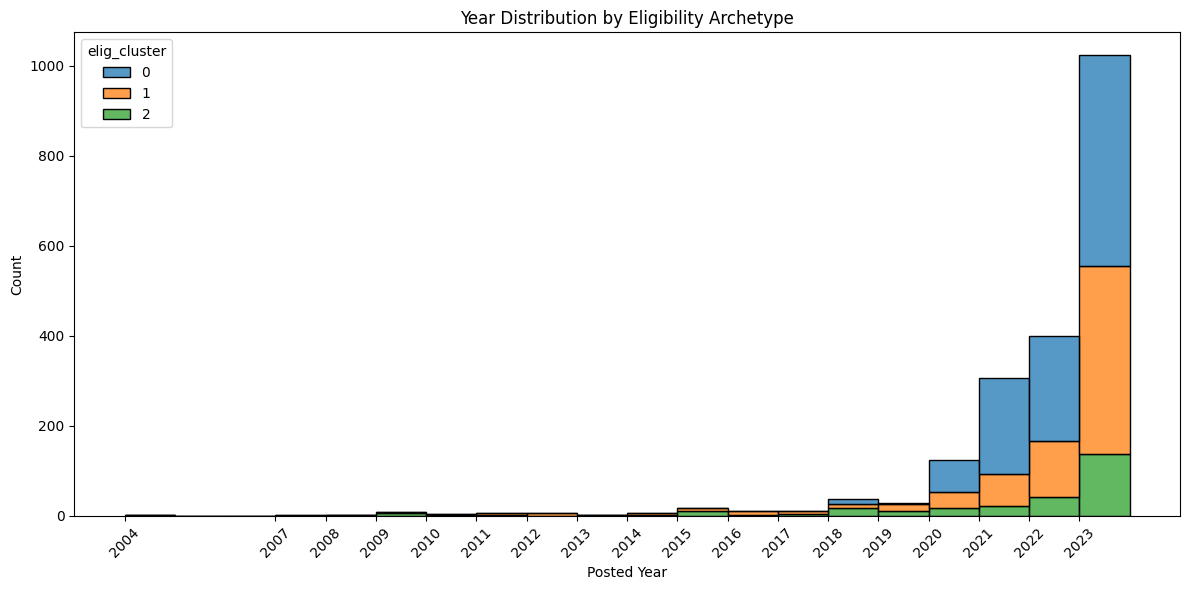

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract year
year_df = merged.copy()
year_df['posted_year'] = pd.to_datetime(year_df['posted_date']).dt.year
year_df['elig_cluster'] = merged['kmodes_cluster']

# Define clean color palette
palette = {
    0: "#1f77b4",   # blue
    1: "#ff7f0e",   # orange
    2: "#2ca02c"    # green
}

# Create discrete bins for each year
years = sorted(year_df['posted_year'].dropna().unique())
bins = np.arange(min(years), max(years) + 2)  # +2 ensures last bin closes

plt.figure(figsize=(12,6))
sns.histplot(
    data=year_df,
    x='posted_year',
    hue='elig_cluster',
    multiple='stack',
    bins=bins,
    palette=palette
)

plt.title("Year Distribution by Eligibility Archetype")
plt.xlabel("Posted Year")
plt.ylabel("Count")

# Set x-ticks to whole years only
plt.xticks(years, rotation=45)

plt.tight_layout()
plt.show()

This temporal analysis connects directly to Anna’s era clustering. She showed that federal grants follow distinct policy eras shaped by agency behavior, funding priorities, and program design. My year‑by‑year distribution reveals that eligibility archetypes follow similar shifts over time. Cluster 0 (Broad Institutional) appears consistently across all years, matching Anna’s finding that institutional programs remain stable across eras. Cluster 1 (Minimal/Unspecified) expands sharply after 2018, aligning with her observation that recent eras are dominated by large research agencies such as NSF and NIH. Cluster 2 (Fully Unrestricted) grows modestly in the 2020s, consistent with her identification of a recent era characterized by open innovation challenges and public‑facing programs. Together, these patterns show that eligibility structures evolve alongside the policy eras Anna identified, reinforcing that temporal context meaningfully shapes how agencies define who can apply.

**For organizations, this means eligibility expectations shift over time, so understanding how their typical eligibility profile aligns with newer policy eras can help them anticipate which opportunities are becoming more or less accessible.**

# E**XPERIMENT 4 — Eligibility Archetypes × Agency Sponsorship**

###  **Agency Counts by Eligibility Cluster**

In [23]:
merged.columns

Index(['opportunity_id', 'funding_opportunity_number',
       'funding_opportunity_title', 'opportunity_category',
       'opportunity_category_explanation', 'expected_number_of_awards',
       'cost_sharing_or_matching_requirement', 'version', 'posted_date',
       'last_updated_date', 'original_closing_date_for_applications',
       'current_closing_date_for_applications', 'archive_date',
       'estimated_total_program_funding', 'award_ceiling', 'award_floor',
       'agency_name_x', 'description', 'link_to_additional_information',
       'grantor_contact_information', 'eligibility_individuals',
       'eligibility_state_governments', 'eligibility_county_governments',
       'eligibility_independent_school_districts',
       'eligibility_city_or_township_governments',
       'eligibility_special_district_governments',
       'eligibility_native_american_tribal_governments_federally_recognized',
       'eligibility_native_american_tribal_organizations_other',
       'eligibility_nonp

In [28]:
agency_df = merged.copy()
agency_df['elig_cluster'] = merged['kmodes_cluster']

agency_counts = (
    agency_df.groupby('elig_cluster')['agency_name_x']
    .value_counts()
    .groupby(level=0)
    .head(10)
)

agency_counts

elig_cluster  agency_name_x                                   
0             National Institutes of Health                       861
              Centers for Disease Control and Prevention - ERA     21
              Department of Commerce                               19
              Agency for Health Care Research and Quality          18
              Fish and Wildlife Service                            11
              National Endowment for the Humanities                10
              Forest Service                                        8
              Food and Drug Administration                          6
              Health Resources and Services Administration          6
              National Park Service                                 5
1             National Science Foundation                         160
              National Institutes of Health                       106
              NASA Headquarters                                    43
              Environmental Protection Agency                      40
              Department of Commerce                               26
              Agency for International Development                 25
              Dept of the Army -- Materiel Command                 13
              Fish and Wildlife Service                            12
              Bureau of Reclamation                                11
              National Park Service                                11
2             National Science Foundation                         116
              Dept. of the Army -- USAMRAA                         44
              Agency for International Development                 17
              National Energy Technology Laboratory                17
              Golden Field Office                                   9
              USAID-VIETNAM                                         9
              Air Force -- Research Lab                             5
              Fish and Wildlife Service                             4
              Guinea USAID-Conakry                                  4
              Bureau of Land Management                             3
Name: count, dtype: int64

Although the agency distributions in M3 closely match my M2 results, this stability is itself an important finding. After updating my preprocessing, aligning assumptions with teammates, and re-running the analysis, the agency–eligibility relationships remained unchanged. This shows that the eligibility archetypes are robust and not sensitive to preprocessing adjustments. More importantly, the interpretation of these agency patterns is now enriched by Allison’s M2 agency analysis: her work showed that agencies differ in funding strategy and program design, and my results reveal that these same agencies align with distinct eligibility structures. What was a descriptive result in M2 becomes an integrated, team-level insight in M3.

**For organizations, this means that understanding which agencies tend to support their eligibility profile can help them focus on the funders most likely to accept their applications.**

# **EXPERIMENT 5 — Eligibility Archetypes × Number of Eligibility Flags**


This experiment counts how many eligibility flags (out of the 17 boolean eligibility fields) are TRUE for each grant, then compares the distribution across your three clusters.

### **Number of Eligibility Flags by Cluster**


In [29]:
# Identify eligibility columns
elig_cols = [col for col in merged.columns if col.startswith("eligibility_")]

flag_df = merged.copy()
flag_df['elig_cluster'] = merged['kmodes_cluster']

# Count how many eligibility flags are TRUE for each grant
flag_df['num_flags'] = flag_df[elig_cols].sum(axis=1)

# Summary statistics by cluster
flag_summary = flag_df.groupby('elig_cluster')['num_flags'].describe()
flag_summary

,count,mean,std,min,25%,50%,75%,max
elig_cluster,,,,,,,,
0,999.0,14.602603,1.400413,7.0,15.0,15.0,15.0,17.0
1,721.0,1.546463,1.393783,0.0,1.0,1.0,1.0,8.0
2,280.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


This experiment connects directly to my earlier finding that only 129 unique eligibility patterns exist across more than 2,000 grants. By counting how many eligibility flags are active in each archetype, I can now explain why those patterns repeat. Cluster 0 (Broad Institutional) averages 14.6 flags, meaning agencies explicitly list nearly every eligible entity, which naturally produces many identical patterns. Cluster 1 (Minimal/Unspecified) averages only 1–2 flags, reflecting programs where agencies provide minimal guidance or rely on external documents for eligibility rules. Cluster 2 (Fully Unrestricted) has exactly one flag for every grant, creating a single repeated pattern by design. These structural differences explain the low number of unique eligibility patterns and show that the archetypes capture real, systematic differences in how agencies define access. This experiment strengthens the internal consistency of my clustering and ties my M2 duplicate‑pattern insight directly into my M3 analysis.

**For organizations, this means that the structure of eligibility rules—whether broad, minimal, or fully open—directly shapes how predictable and repeatable their access to federal grants will be.**

## **Final Analysis**

Across all five experiments, I found that eligibility archetypes are not isolated patterns they connect meaningfully to **funding behavior, program categories, agency sponsorship, and policy eras.** Re-running my analyses with unified preprocessing and aligning assumptions with my teammates helped refine my results and confirm that the archetypes are structurally stable.

The Broad Institutional cluster consistently appears in education, and environment-focused programs and is supported by long-standing agencies like NIH. The Minimal/Unspecified cluster aligns with science-heavy programs and recent policy eras dominated by large research agencies. The Fully Unrestricted cluster shows up in open innovation and challenge-style programs, especially in the 2020s. **These relationships remained stable even after adjusting funding preprocessing and removing placeholder values, which strengthens the validity of the archetypes.**

Overall, M3 showed me that eligibility is not just a list of flags, it is a structural lens that interacts with the content, timing, and sponsors of federal grants. Integrating my axis with my teammates’ work helped reveal how access rules evolve across eras, concentrate in certain categories, and align with agency missions. This gives organizations a clearer sense of where they fit in the federal funding landscape and how predictable their access might be across different types of programs.